In [279]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
from scipy import stats
import matplotlib.pyplot as plt
%matplotlib inline
# ********************************* For Machine Learning Models***************************
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.formula.api import ols
import statsmodels.api as sm


In [280]:
# Load Dataset
df=pd.read_csv("insurance.csv")


In [281]:
df.shape
# print("Number of rowrs = {} and number of coulummn ={} in insurance Data frame".format(df.shape[0],df.shape[1]))

(1338, 7)

In [282]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0.0,yes,southwest,16884.92400
1,18,male,33.770,1.0,no,southeast,1725.55230
2,28,male,33.000,3.0,no,southeast,4449.46200
3,33,male,22.705,0.0,no,northwest,21984.47061
4,32,male,28.880,0.0,no,northwest,3866.85520


In [283]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1337 non-null   float64
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(3), int64(1), object(3)
memory usage: 73.3+ KB


In [284]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1337.000000,1338.000000
mean,39.207025,30.663397,1.094241,13270.422265
std,14.049960,6.098187,1.205689,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


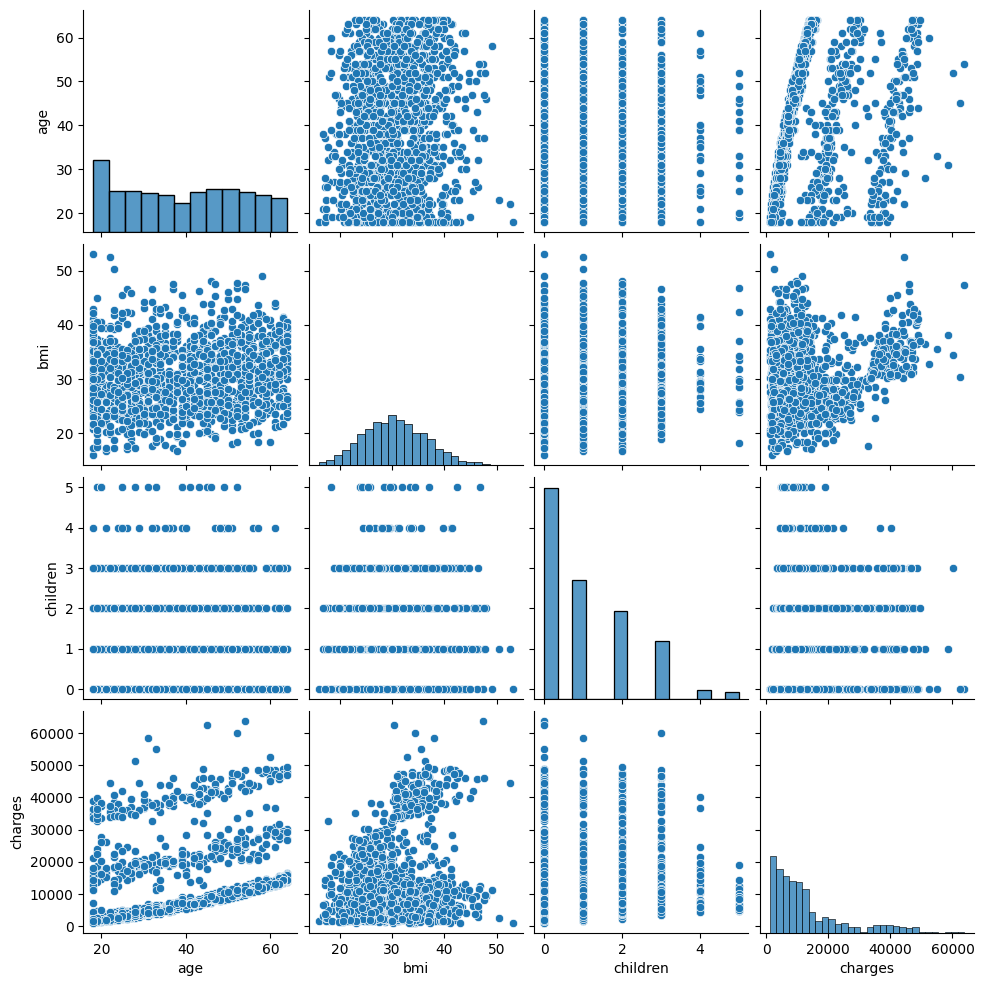

In [285]:
sns.pairplot(df)

In [286]:
# fetching column names
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [287]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    1
smoker      0
region      0
charges     0
dtype: int64

In [288]:
df['children'].mean()

1.094240837696335

In [289]:
df['children'].fillna(df['children'].mean(),inplace=True)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_23888\197029945.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['children'].fillna(df['children'].mean(),inplace=True)


In [290]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [291]:
# Chagne the data type of children
df['children']=df['children'].round().astype(int)


In [292]:
# handling duplicate values
df.duplicated().sum()
#which value is duplicate if i want to see that then how can i see 

1

In [293]:
duplicates = df[df.duplicated(keep=False)]
print(duplicates)


     age   sex    bmi  children smoker     region    charges
195   19  male  30.59         0     no  northwest  1639.5631
581   19  male  30.59         0     no  northwest  1639.5631


In [294]:
df[df.duplicated(keep= False)]

,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


In [295]:
df.drop_duplicates(inplace=True)

In [296]:
#calculating average age,bmi,children,expenses group by region 
grouped_data=df.groupby('region')[['age','bmi','children','charges']].mean()
print(grouped_data)

                 age        bmi  children       charges
region                                                 
northeast  39.268519  29.173503  1.043210  13406.384516
northwest  39.259259  29.195494  1.151235  12450.840844
southeast  38.939560  33.355989  1.049451  14735.411438
southwest  39.455385  30.596615  1.141538  12346.937377


### Measure the skewness of 'bmi','age', and 'charges' columns

In [297]:
df_attr=df.iloc[:,[0,2,6]] #select age,bmi and charges columns 
print("skewness of 'age','bmi' and 'charges' columns is follows:")
df_attr.skew(axis= 0,skipna=True)

skewness of 'age','bmi' and 'charges' columns is follows:


age        0.054781
bmi        0.283914
charges    1.515391
dtype: float64

### checking the presence of outliers in "bmi","age"and "charges columns

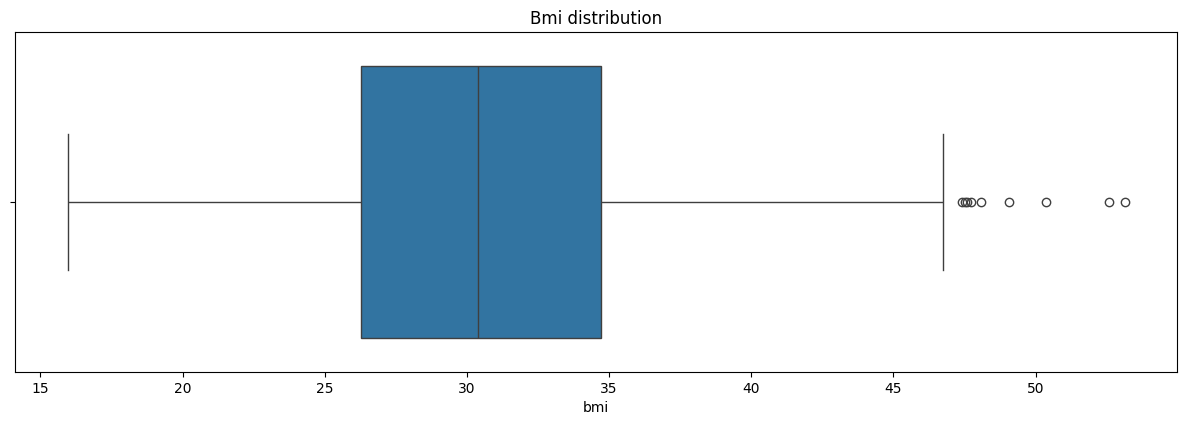

In [298]:
# outliers in BMI
plt.figure(figsize=(15,15))
plt.subplot(3,1,1)
plt.title("Bmi distribution")
sns.boxplot(x=df['bmi'])
plt.show()

there are few points between 47 and 55 these are outliers as there are not included in the box of other observation i.e  no where near the quartiles.

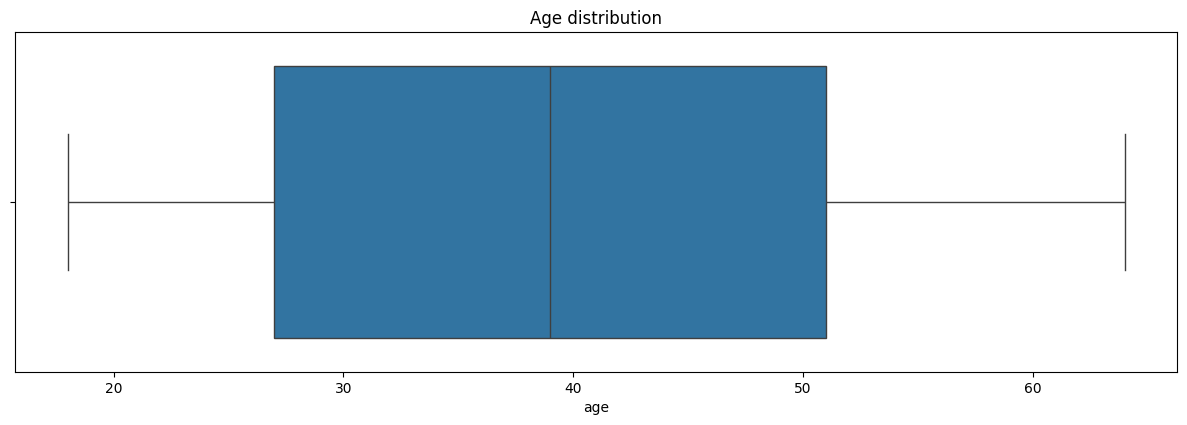

In [299]:
# OUTLIERS IN AGE
plt.figure(figsize=(15,15))
plt.subplot(3,1,1)
plt.title("Age distribution")
sns.boxplot(x=df['age'])
plt.show()

There is no Outlier in age column

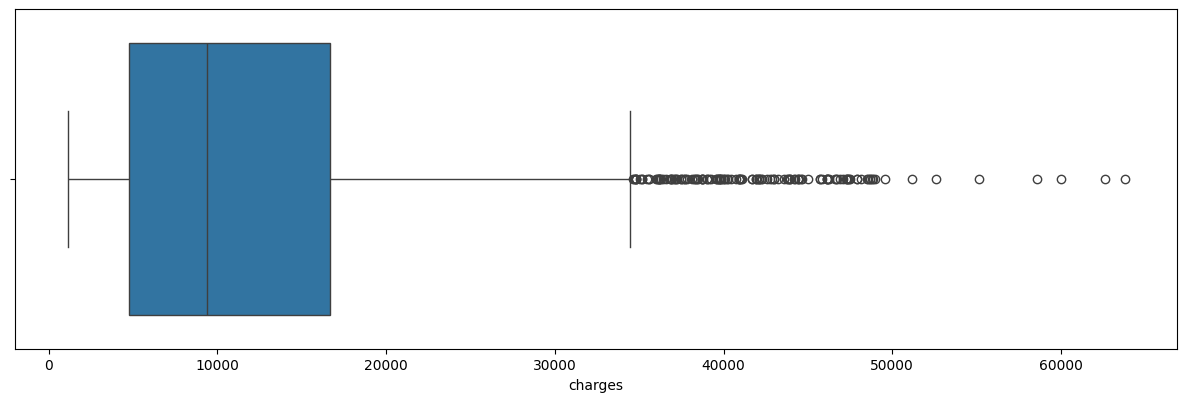

In [300]:
# outliers in charges
plt.figure(figsize=(15,15))
plt.subplot(3,1,1)
sns.boxplot(x=df['charges'])
plt.show()

**More points between 35000 to 55000,these are outliers as there are not included in the box of other observation i.e no where near the quartiles**


### Distribution of categorical columns (include children)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_23888\2741038292.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sex',data=df,palette="Set1")


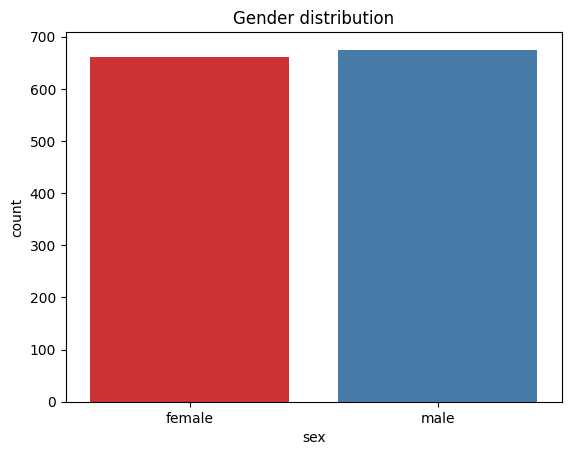

In [301]:
sns.countplot(x='sex',data=df,palette="Set1")
plt.title("Gender distribution")
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_23888\2085831050.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='children',data=df,palette="Set2")


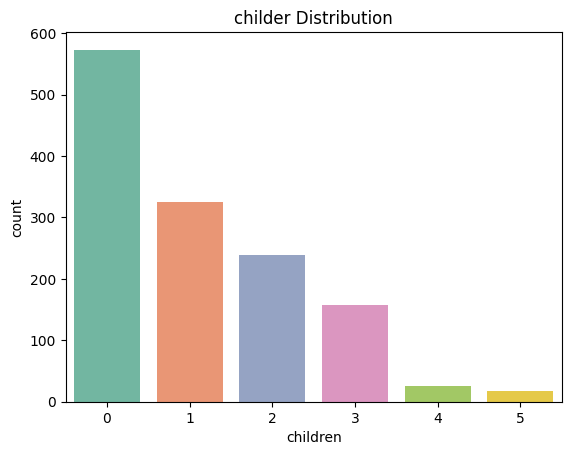

In [302]:
sns.countplot(x='children',data=df,palette="Set2")
plt.title("childer Distribution")
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_23888\3030538353.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='smoker',data=df,palette="Set2")


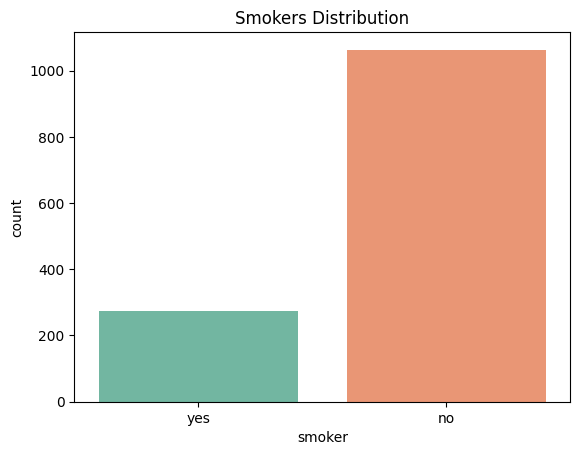

In [303]:
sns.countplot(x='smoker',data=df,palette="Set2")
plt.title("Smokers Distribution")
plt.show()

There anre more non-smokers than smokers in insurance data frame 

C:\Users\ASUS\AppData\Local\Temp\ipykernel_23888\2226667240.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="region",data=df,palette="Set2")


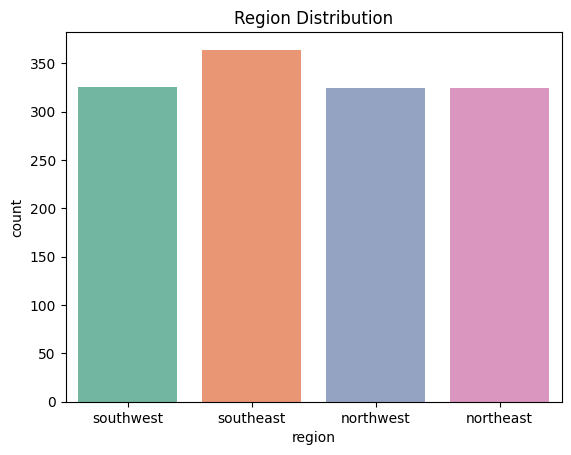

In [304]:
#  Region Distribution
sns.countplot(x="region",data=df,palette="Set2")
plt.title("Region Distribution")
plt.show()

## Pair Plot That INcludes all the columns of the data frame

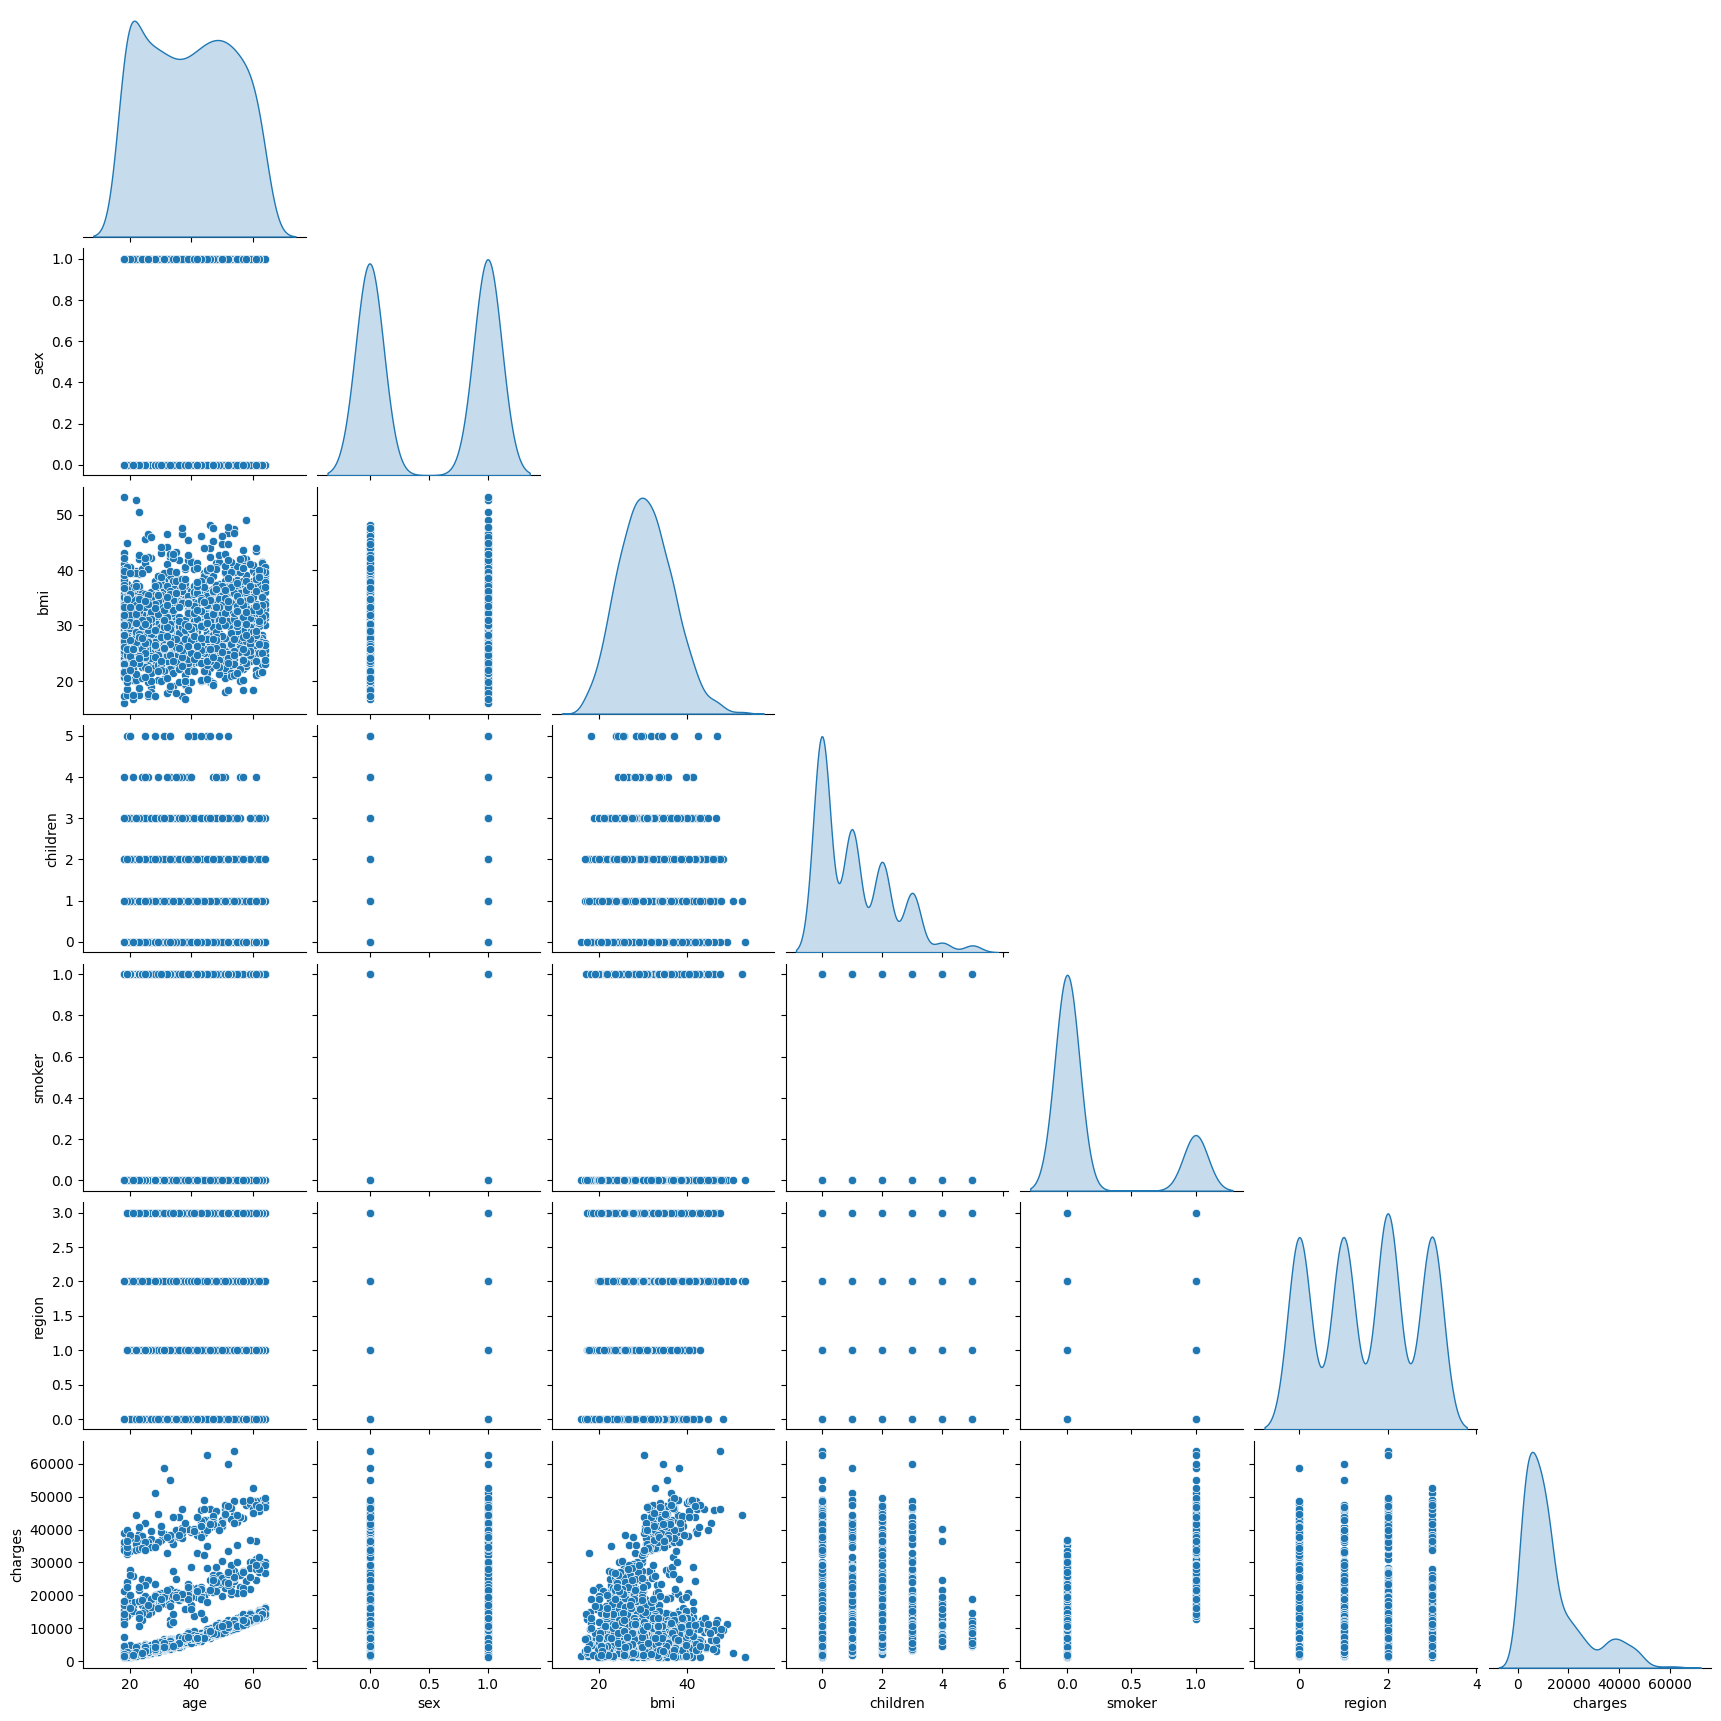

In [305]:
import copy
df_encode=copy.deepcopy(df)
df_encode.loc[:,['sex','smoker','region']]=df_encode.loc[:,['sex','smoker','region']].apply(LabelEncoder().fit_transform)
sns.pairplot(df_encode,diag_kind='kde',corner=True)
plt.show()


By looking into above graph, we can infer below points
* Smokers claimed more money than non smokers
* Bmi of male and female customer is almost same

# Hypothesis Testing

<Axes: xlabel='age', ylabel='charges'>

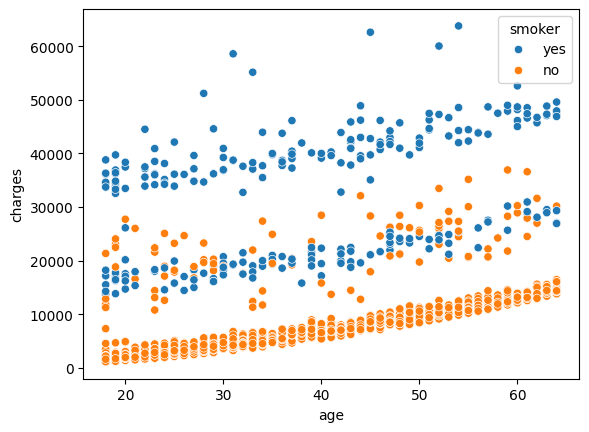

In [306]:
# Check the charges of smokers and non-smokers across different ages
sns.scatterplot(x='age',y='charges',hue='smoker',data=df)

In [307]:
# Hypothesis Testing Examples
smokers=df[df['smoker']=='yes']['charges']
non_smokers=df[df['smoker']=='no']['charges']
t_stat,p_val=stats.ttest_ind(smokers,non_smokers)
print(p_val)
print(t_stat)
if(p_val>=0.5):
    print("it is  coincidence ")
else:
    print("it is not a coincidence  ")

1.4067220949376498e-282
46.64479459840305
it is not a coincidence  


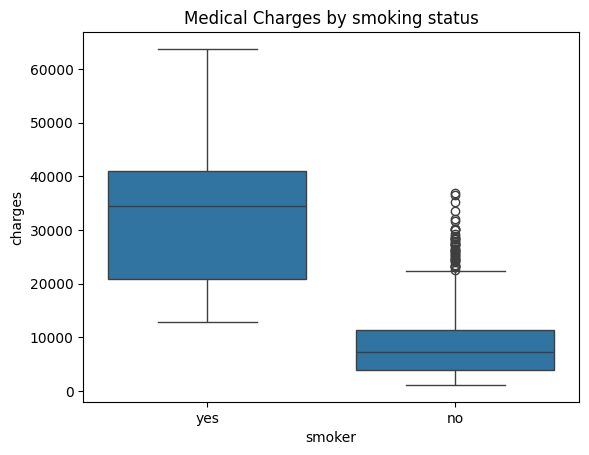

In [308]:
# visulization
sns.boxplot(x='smoker',y='charges',data=df)
plt.title('Medical Charges by smoking status')
plt.show()

In [309]:
# Decide to reject or accept null Hypothesis
reject_null=False
if p_val<0.05:
    reject_null=True
else:
    reject_null=False
print("Reject NUll?" +str(reject_null))

Reject NUll?True


### Does Charges of males differ significantly from that of females?

In [310]:
df.sex.value_counts()

sex
male      675
female    662
Name: count, dtype: int64

<Axes: xlabel='age', ylabel='charges'>

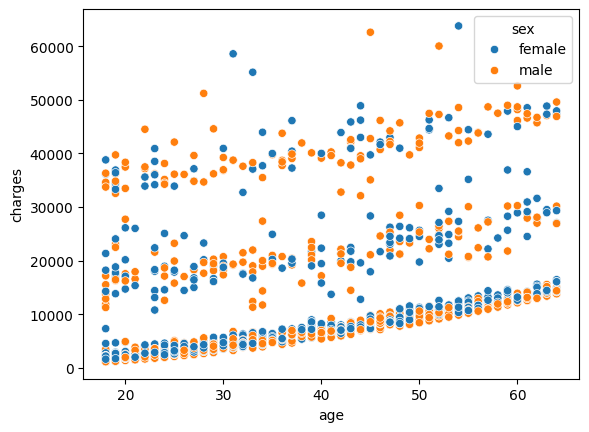

In [311]:
#check the charges of male and female customers accross different ages
sns.scatterplot(x='age',y='charges',hue="sex",data=df)

In [312]:
#Hypothesis Testing btw male and female
male=df[df['sex']=='male']['charges']
female=df[df['sex']=='female']['charges']
stats.ttest_ind(male,female)
if(p_val<0.05):
    print("it is not Coincidence")
else:
    print("It is coincidence")

it is not Coincidence


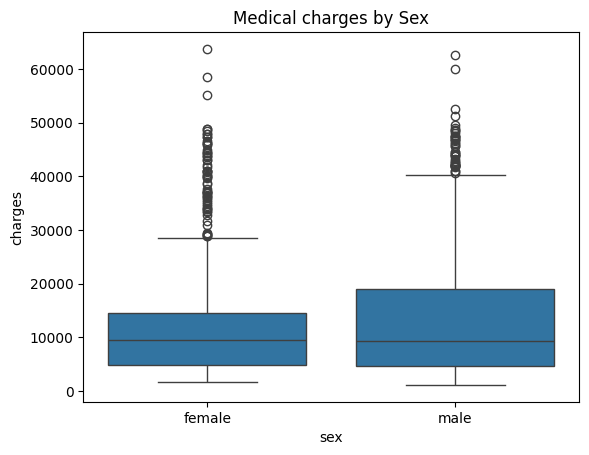

In [313]:
sns.boxplot(x="sex",y="charges",data=df)
plt.title("Medical charges by Sex")
plt.show()

In [314]:
# Hypothesis Testing on bmi and price(will test whether there is a significant difference in charges between people with normal BMI and those with high BMI.)

#split into two groups
normal_bmi=df[df['bmi']<=25]['charges']
high_bmi=df[df['bmi']>25]['charges']
t_stat,p_val=stats.ttest_ind(normal_bmi,high_bmi)

In [315]:
print("t-statistic",t_stat)
print("p-value",p_val)
# conclusion
alpha=0.05
if p_val < alpha:
    print("Reject the null hypothesis :Signicant diffrence in charges")
else:
    print("Fail to reject the null hypothesis :No significant difference")


t-statistic -4.332975576702388
p-value 1.5812917593118903e-05
Reject the null hypothesis :Signicant diffrence in charges


In [316]:
#create the new Column for BMI category
df['bmi_category'] = df['bmi'].apply(lambda x: "Normal(<=25)" if x <= 25 else "High(>25)")


In [317]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges',
       'bmi_category'],
      dtype='object')

C:\Users\ASUS\AppData\Local\Temp\ipykernel_23888\577842364.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='bmi_category',y="charges",data=df,palette="Set2")


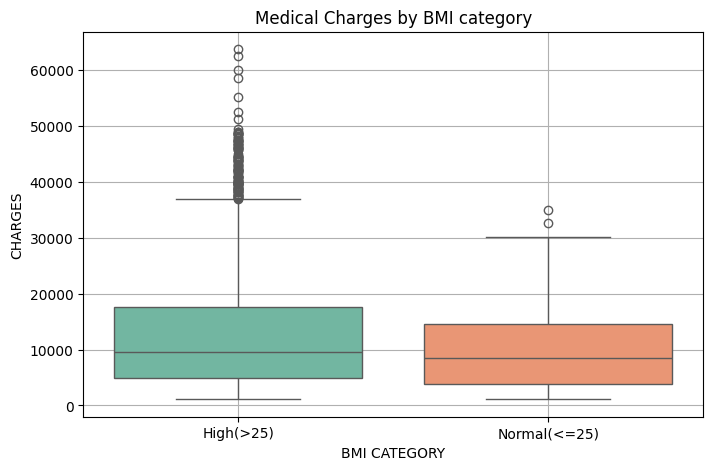

In [318]:
plt.figure(figsize=(8,5))
sns.boxplot(x='bmi_category',y="charges",data=df,palette="Set2")
plt.title("Medical Charges by BMI category")
plt.xlabel("BMI CATEGORY")
plt.ylabel("CHARGES")
plt.grid(True)
plt.show()

In [319]:
df[['bmi','bmi_category']].head()

,bmi,bmi_category
0,27.900,High(>25)
1,33.770,High(>25)
2,33.000,High(>25)
3,22.705,Normal(<=25)
4,28.880,High(>25)


In [320]:
round(df['age'].mean())

39

In [321]:
# Hypothesis testing btw Age and charges
Chlid=df[df['age']<39]['charges']
Adult=df[df['age']>=39]['charges']
t_stat,p_val=stats.ttest_ind(Chlid,Adult)
print(t_stat)
print(p_val)
if(p_val<0.5):
    print("difference is real ")
else:
    print("its a coincidence")

-9.59729722592182
3.876066121115055e-21
difference is real 


In [322]:

df['Age_category']=df['age'].apply(lambda x: "Child" if x<39 else "Adult")

In [323]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges',
       'bmi_category', 'Age_category'],
      dtype='object')

C:\Users\ASUS\AppData\Local\Temp\ipykernel_23888\127605251.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Age_category",y='charges',data=df,palette="Set2")


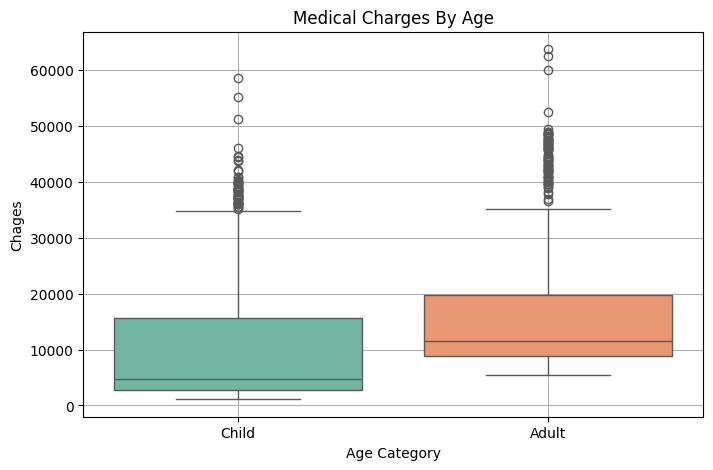

In [324]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Age_category",y='charges',data=df,palette="Set2")
plt.title("Medical Charges By Age")
plt.xlabel("Age Category")
plt.ylabel("Chages")
plt.grid(True)
plt.show()

In [325]:
#Between Region and Sex
from scipy.stats import chi2_contingency
Contigency_table =pd.crosstab(df["region"],df['sex'])
print(Contigency_table)

sex        female  male
region                 
northeast     161   163
northwest     164   160
southeast     175   189
southwest     162   163


In [326]:

chi2, p, dof, expected = chi2_contingency(Contigency_table)
print(f"Chi-Square Statistic= {chi2}")
print(f"p-value = {p}")


Chi-Square Statistic= 0.476909551071918
p-value = 0.9239341965125791


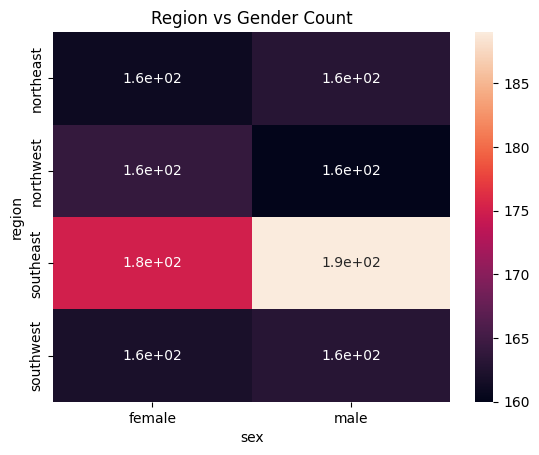

In [327]:
# Visualization (HeatMap)
sns.heatmap(Contigency_table,annot=True,)
plt.title("Region vs Gender Count")
plt.show()


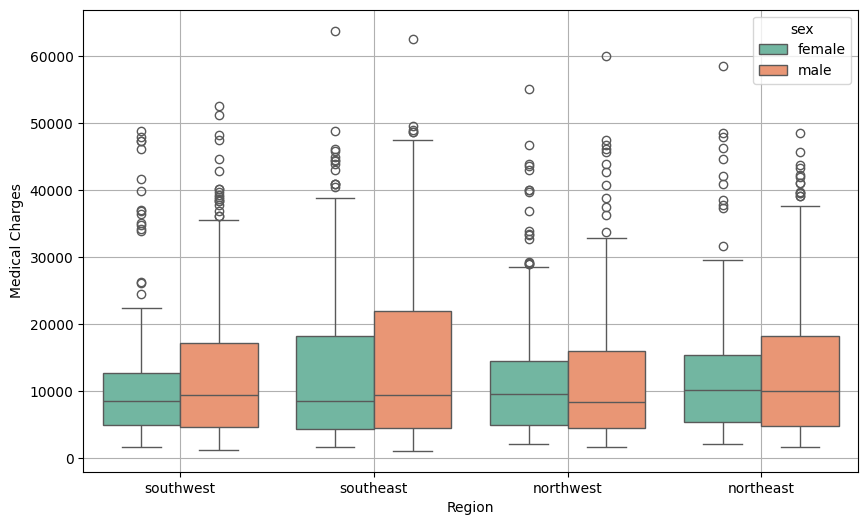

In [328]:
plt.figure(figsize=(10,6))
sns.boxplot(x="region",y="charges",hue='sex',data=df,palette="Set2")
plt.xlabel("Region")
plt.ylabel("Medical Charges")
plt.grid(True)
plt.show()

## B.Does Bmi of male Differ Significantly from that of females


In [329]:
# checking howmany males and female customers in Insurance Data Frame
df.sex.value_counts()

sex
male      675
female    662
Name: count, dtype: int64

<Axes: xlabel='age', ylabel='bmi'>

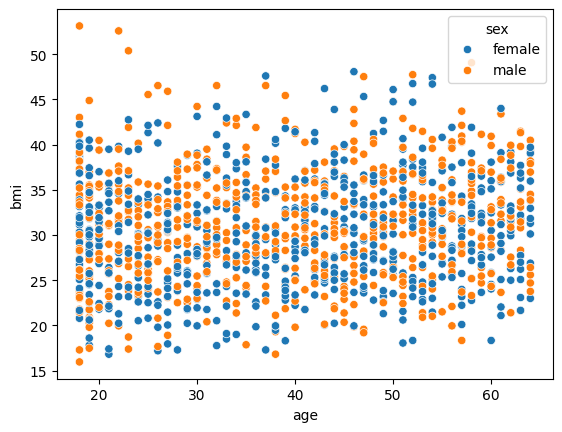

In [330]:
#  Check the bmi of male and female customers accross different ages
sns.scatterplot(x='age',y='bmi',hue='sex',data=df)

In [331]:
# Calculating P_vale using T_score
male_bmi=df[df['sex']=='male'].bmi
female_bmi=df[df['sex']=='female'].bmi
t_stat,p_val=stats.ttest_ind(male_bmi,female_bmi)
print("t_statistic =",t_stat)
print("P_value",p_val)
if(p_val<0.05):
    print(True)
else:
    print(False)


t_statistic = 1.6970672301298684
P_value 0.08991704324931137
False


## c.Is the proportion of smokers significantly different in different genders?


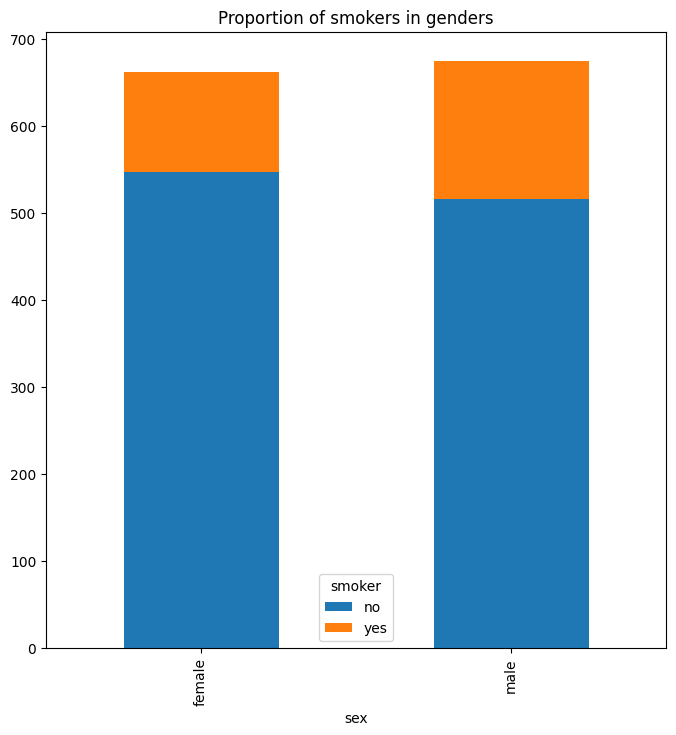

In [332]:
# Check the smokers of male and female customers accross different ages
smokers_gender_table=pd.crosstab(index=df['sex'],columns=df['smoker'])
smokers_gender_table.plot(kind="bar",figsize=(8,8),stacked=True)
plt.title("Proportion of smokers in genders")
plt.show()

#### By lokking this graph we can say "The propertion of smokers in genders are not equal".But is the difference statistically significant?

In [333]:
#  checking t_test and p_value
n_males = df[df['sex']=='male'].shape[0]
n_females = df[df['sex']=='female'].shape[0]

male_smokers = df[(df['sex']=='male') & (df['smoker']=='yes')].shape[0]
female_smokers = df[(df['sex']=='female') & (df['smoker']=='yes')].shape[0]

print([female_smokers, male_smokers], [n_females, n_males])
print(f"Proportion of smokers in females: {round(female_smokers/n_females,2)*100}%")
print(f"Proportion of smokers in males: {round(male_smokers/n_males,2)*100}%")

# T_test and P_value
stats,p_val=proportions_ztest([female_smokers,male_smokers],[n_females,n_males])
print("t_statistics =",t_stat)
print("p_value",p_val)
# Hypothesis testing
if(p_val<0.05):
    print(True)
else:
    print(False)


[115, 159] [662, 675]
Proportion of smokers in females: 17.0%
Proportion of smokers in males: 24.0%
t_statistics = 1.6970672301298684
p_value 0.005098746217145657
True


### is the distribution of bmi across women with no children,one child and two children,the same ?

In [334]:
# check the bmi of women with no children,one child and two children
zero_child=df[df['children']==0]
women_zero_child_bmi=zero_child[zero_child['sex']=='female'].bmi

one_child=df[df['children']==1]
women_one_child_bmi=one_child[one_child['sex']=='female'].bmi

two_child=df[df['children']==2]
women_two_child_bmi=two_child[two_child['sex']=='female'].bmi

children_bmi_df=pd.DataFrame()

df1=pd.DataFrame({'children':'zero','bmi':women_zero_child_bmi})
df2=pd.DataFrame({'children':'one','bmi':women_one_child_bmi})
df3=pd.DataFrame({'children':'two','bmi':women_two_child_bmi })
 
children_bmi_df = pd.concat([df1, df2, df3], ignore_index=True)


<Axes: xlabel='children', ylabel='bmi'>

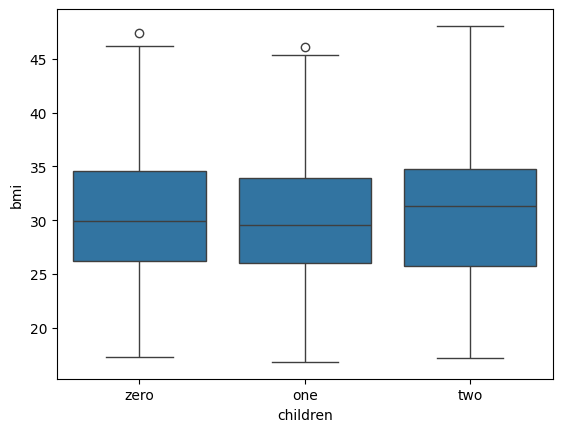

In [335]:
sns.boxplot(x='children',y='bmi',data=children_bmi_df)

### Calculate P_value using ANOVA table 

In [336]:
mod=ols('bmi ~ children',data=children_bmi_df).fit()
aov_table=sm.stats.anova_lm(mod, typ=2)
print(aov_table)
p_val=aov_table["PR(>F)"][0]
if(p_val<0.5):
    print(True)
else:
    print(False)

                sum_sq     df         F    PR(>F)
children     24.590123    2.0  0.334472  0.715858
Residual  20695.661583  563.0       NaN       NaN
False


C:\Users\ASUS\AppData\Local\Temp\ipykernel_23888\1668407291.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_val=aov_table["PR(>F)"][0]


# Correlation Analysis:

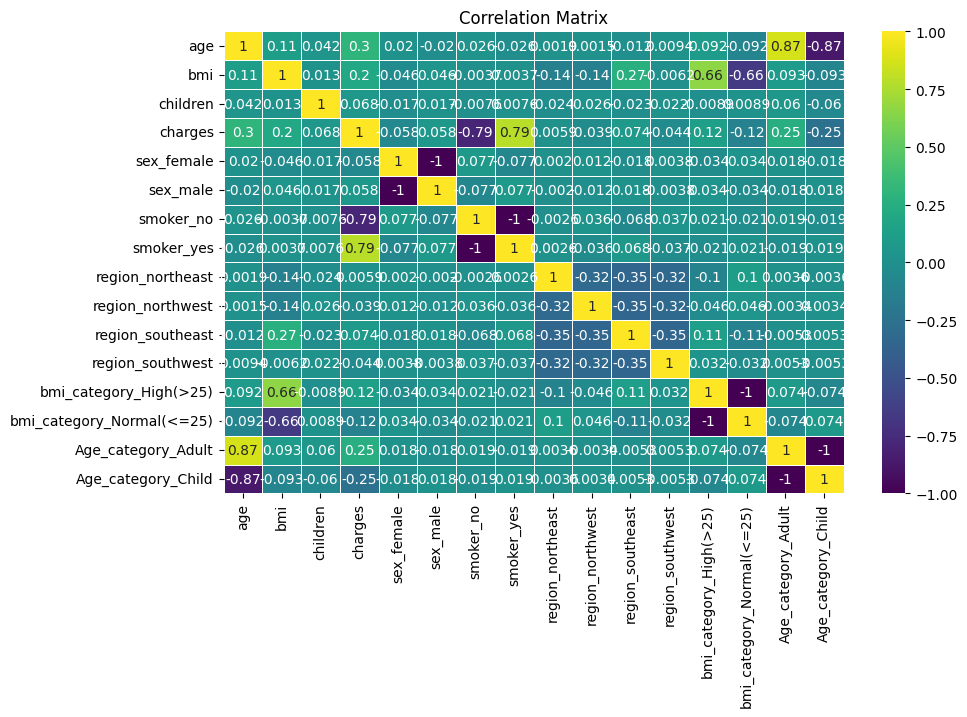

In [337]:
# correlation matrix
insurance=pd.get_dummies(df,drop_first=False)
plt.figure(figsize=(10,6))
sns.heatmap(insurance.corr(), annot=True, cmap="viridis", linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

#### Input and output variables

In [338]:
df=pd.get_dummies(df,drop_first=True)

In [339]:
# Dividing the dataset into input and output variables.
x=df.drop('charges',axis=1)
y=df['charges']

#### Splitting data

In [340]:
# Dividing the data into Train-test split.
x_train,x_test,y_train,y_test=train_test_split(x,y, test_size=0.3, random_state=42)

#### standard Scaling

In [341]:
# Performing Standard Scaling to put all numerical Features on a similar scale
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.fit_transform(x_test)

## Decision Tree Regressor

In [ ]:
# converting a DecisionTreeRegressor Model
dt=DecisionTreeRegressor(max_depth=5,min_samples_leaf=10)
dt.fit(x_train,y_train)

DecisionTreeRegressor(max_depth=5, min_samples_leaf=10)

### Training Accuracy

In [343]:
# Predicting the test data 
dt_train_predictions=dt.predict(x_train)
# Evaluating the model 
print("MAE for train set", mean_absolute_error(y_train,dt_train_predictions))
print("MSE for train set :",mean_squared_error(y_train,dt_train_predictions))
print("RMSE for train set :",np.sqrt(mean_squared_error(y_train,dt_train_predictions)))
print("R2 Score for train set:",r2_score(y_train,dt_train_predictions))

MAE for train set 2319.909963816288
MSE for train set : 17404453.82280896
RMSE for train set : 4171.864549911581
R2 Score for train set: 0.8718288204944408


### Testing Accuracy

In [344]:
#Predicting the test data
dt_test_predictions=dt.predict(x_test)
# Evaluating the model.
print("MAE for test set: ",mean_absolute_error(y_test,dt_test_predictions))
print("MSE for test set: ",mean_squared_error(y_test,dt_test_predictions))
print("RMSE for test set:",np.sqrt(mean_squared_error(y_test,dt_test_predictions)))
print("R2 Score for test set :",r2_score(y_test,dt_test_predictions))

MAE for test set:  2380.2373950143656
MSE for test set:  21108703.737075344
RMSE for test set: 4594.420935991318
R2 Score for test set : 0.876642201629596


# Hyperparameter tuning

##### Performing Bayesian-optimization Cross Validation on Decision Tree Regressor

In [345]:
pip install bayesian-optimization scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [350]:
# Importing necessary Libraries for hyperparameter tuning
from sklearn.model_selection import cross_val_score
from bayes_opt import BayesianOptimization

In [347]:
#  Hyperparameter tuning 
# Defining the objective function
def dt_cv_r2(max_depth ,min_samples_split,min_samples_leaf):
    estimator=DecisionTreeRegressor(
        max_depth=int(max_depth),
        min_samples_split=int(min_samples_split),
        min_samples_leaf=int(min_samples_leaf),
        random_state=42
    )
    # Cross -validated R² Score
    cval=cross_val_score(estimator,x,y,scoring="r2",cv=5,error_score='raise')
    return cval.mean()

In [348]:
# Bounds for hyperparameters 
pbounds={
    'max_depth':(1,20),
    'min_samples_split':(2,20),
    'min_samples_leaf':(1,20)
}

In [ ]:
#  Bayesian Optimization
optimizer=BayesianOptimization(
    f=dt_cv_r2,
    pbounds=pbounds,
    random_state=42,
    verbose=2
)
optimizer.maximize(
    init_points=10, #Number of random initial points
    n_iter=50 #Number of iterations to run
)

|   iter    |  target   | max_depth | min_sa... | min_sa... |
-------------------------------------------------------------
| 1         | 0.8448    | 8.116     | 19.06     | 15.18     |
| 2         | 0.8007    | 12.37     | 3.964     | 4.808     |
| 3         | 0.8193    | 2.104     | 17.46     | 12.82     |
| 4         | 0.7985    | 14.45     | 1.391     | 19.46     |
| 5         | 0.8206    | 16.82     | 5.034     | 5.273     |
| 6         | 0.8497    | 4.485     | 6.781     | 11.45     |
| 7         | 0.829     | 9.207     | 6.533     | 13.01     |
| 8         | 0.8425    | 3.65      | 6.551     | 8.595     |
| 9         | 0.8403    | 9.665     | 15.92     | 5.594     |
| 10        | 0.8404    | 10.77     | 12.26     | 2.836     |
| 11        | 0.6178    | 1.208     | 4.226     | 13.75     |
| 12        | 0.8496    | 5.865     | 7.005     | 9.703     |
| 13        | 0.8497    | 4.603     | 10.26     | 10.65     |
| 14        | 0.8441    | 7.108     | 11.59     | 6.582     |
| 15    